
# 02 — Mini N-body example with spectra

Run a tiny PM evolution, produce density snapshots, and inspect spectra using class plotting helpers.


In [1]:

import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")


'cpu'

In [2]:

import jax
import jax_cosmo as jc
import matplotlib.pyplot as plt
import numpy as np

from fwd_model_tools import gaussian_initial_conditions
from fwd_model_tools.pm import lpt, nbody
from fwd_model_tools.power import angular_cl_flat


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


ERROR:2025-11-25 10:08:06,140:jax._src.xla_bridge:473: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 471, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_OPERATING_SYSTEM


JAX is not using 64-bit precision. This will dramatically affect numerical precision at even moderate L.


In [3]:

# Small configuration for speed
key = jax.random.PRNGKey(1)
mesh_size = (16, 16, 16)
box_size = (200.0, 200.0, 200.0)
flatsky_npix = (48, 48)
cosmo = jc.Planck15()


In [4]:

# 1) Initial conditions and LPT (default P(k))
init_field = gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    cosmo=cosmo,
    flatsky_npix=flatsky_npix,
)
start_a = 0.1
dx_field, p_field = lpt(cosmo, init_field, a=start_a, order=1)


shape of initial force: (16, 16, 16, 3)
growth factor shape: (1,)


In [5]:

# 2) Short N-body run to z=0 producing 3D density snapshots
lightcone_density = nbody(
    cosmo,
    dx_field,
    p_field,
    t1=1.0,
    dt0=0.1,
    nb_shells=2,
    geometry="density",
)


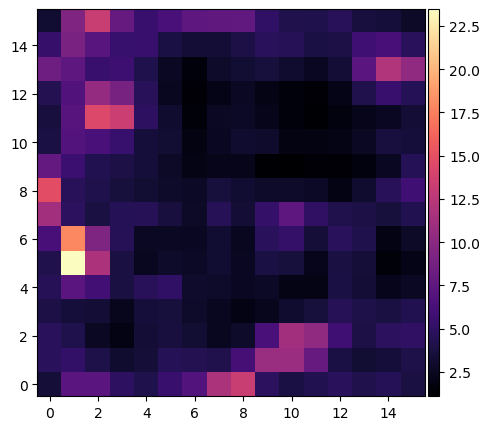

In [6]:

# 3) Inspect the first density snapshot via a projected map
first_density = lightcone_density[0]
flat_proj = first_density.project(nz_slices=4)
fig, ax = flat_proj.plot(cmap="magma", show_colorbar=True)
plt.show()


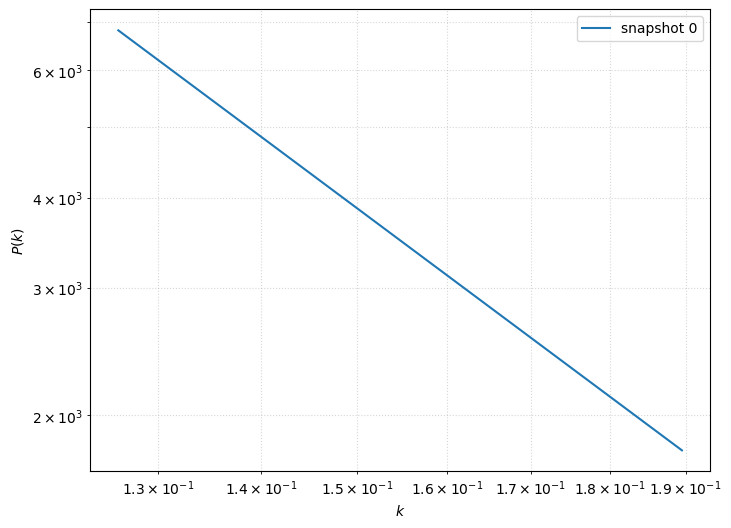

In [7]:

# 4) 3D power spectrum of first snapshot
ps_snapshot = first_density.power()
fig, ax, _ = ps_snapshot.plot(label=["snapshot 0"])
plt.show()


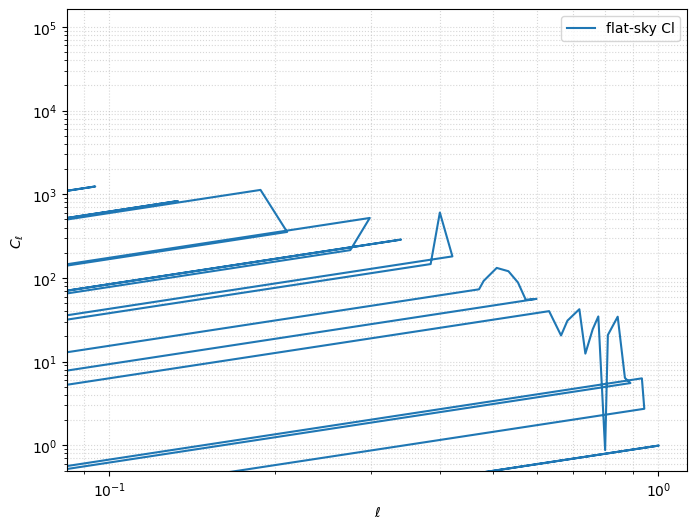

In [8]:

# 5) Angular Cl of the projected snapshot
pixel_size = box_size[0] / flatsky_npix[0]
ell, cl = angular_cl_flat(np.asarray(flat_proj.array), pixel_size=pixel_size)
cl_ps = ps_snapshot.__class__(wavenumber=ell, spectra=cl, name="cl")
fig, ax, _ = cl_ps.plot(label=["flat-sky Cl"])
plt.show()



Notes:
- Configuration is intentionally tiny; increase mesh and steps for real runs.
- The density lightcone has two snapshots; adjust `nb_shells` as needed.
